# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/M-Sheheryar-khan/FlyRank-ML-Internship-Starter-Repo/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The queue ranks every page by `baseline_score` — traffic (`impressions_h1`) × how far its click rate falls below what pages at its own position tier normally get (`ctr_gap`). Two archetypes come out of this, built from the honest, client-holdout-tested signals from w04–w06 (staleness was tested and found FALSE as a signal on this slice, so it's excluded — see the note below):

- **`ctr_underperform_visible` → `review_ctr`**: gets real search visibility (≥100 impressions in the 15-day window) but clicks below its position tier's norm. Split further by position tier for priority (top-3 underperformers are the highest-value fix, since click capture there is worth the most per impression per Finding #3 in the research paper).
- **`no_flag` → `monitor`**: either not visible enough to judge yet, or already converting clicks at or above its tier's norm.

**Decay/refresh insight, stated honestly**: FlyRank's own research paper finds refresh timing is one of its strongest portfolio-wide levers (Finding #4: 3.2x health boost, 57x impression boost for refreshed 365+-day pages). My own signal audit (w04) on this March slice did **not** confirm that pattern here — 99% of content in this slice was updated within 90 days, decline rate didn't rise with staleness, and the oldest bucket had only 26 rows. That's not a contradiction of the paper's larger-portfolio finding; it's a limit of this narrower slice (one month, one dataset cut) where there isn't enough stale content to test the claim. The playbook below leans on the CTR signal, which *did* confirm on this data, and stays silent on refresh timing rather than borrowing the paper's number for a population it wasn't measured on.

In [ ]:
%pip -q install duckdb scikit-learn matplotlib
import os
import duckdb
import numpy as np
import pandas as pd
import json
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
MAR = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"

features = con.sql(f"""
    SELECT content_hash_id,
        SUM(gsc_impressions) AS impressions_h1,
        SUM(gsc_clicks) AS clicks_h1,
        AVG(gsc_avg_position) AS avg_position_h1,
        COUNT(DISTINCT report_date) AS active_days_h1
    FROM {MAR}
    WHERE report_date <= DATE '2026-03-15'
    GROUP BY content_hash_id
    HAVING impressions_h1 >= 20
""").df()
features["ctr_h1"] = features["clicks_h1"] / features["impressions_h1"] * 100

labels = con.sql(f"""
    SELECT content_hash_id, SUM(gsc_impressions) AS impressions_h2
    FROM {MAR} WHERE report_date > DATE '2026-03-15' GROUP BY content_hash_id
""").df()

data = features.merge(labels, on="content_hash_id", how="left")
data["impressions_h2"] = data["impressions_h2"].fillna(0)
data["is_declining"] = (data["impressions_h2"] < 0.8 * data["impressions_h1"]).astype(int)

client_lookup = con.sql(f"SELECT DISTINCT content_hash_id, client_hash_id FROM {MAR}").df()
data = data.merge(client_lookup, on="content_hash_id", how="left")

# --- rebuild the honest, train-only-fit baseline (w06's leakage-audit fix) ---
from sklearn.model_selection import GroupShuffleSplit

data["position_tier"] = pd.cut(data["avg_position_h1"], bins=[0,3,10,20,9999],
                                labels=["1-3","4-10","11-20","21+"])

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, te_idx = next(gss.split(data, groups=data["client_hash_id"]))
train_df, test_df = data.iloc[tr_idx].copy(), data.iloc[te_idx].copy()

train_only_ctr = train_df.groupby("position_tier", observed=True).apply(
    lambda g: g["clicks_h1"].sum() / g["impressions_h1"].sum() * 100
)
data["expected_ctr"] = data["position_tier"].map(train_only_ctr.to_dict()).astype(float)
data["ctr_gap"] = data["expected_ctr"] - data["ctr_h1"]

VISIBLE_MIN_IMPRESSIONS = 100
is_underperform = (data["ctr_gap"] > 0) & (data["impressions_h1"] >= VISIBLE_MIN_IMPRESSIONS)
data["baseline_score"] = np.where(is_underperform, data["impressions_h1"] * data["ctr_gap"], 0)
data["reason_code"] = np.where(is_underperform, "ctr_underperform_visible", "no_flag")
data["action"] = np.where(is_underperform, "review_ctr", "monitor")

print(data.shape)
print("Flagged for review:", (data["action"] == "review_ctr").sum())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(109592, 15)
Flagged for review: 52029


/tmp/ipykernel_2393/3815576939.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_only_ctr = train_df.groupby("position_tier", observed=True).apply(


In [ ]:
archetype_summary = data.groupby(["position_tier", "action"], observed=True).agg(
    n=("content_hash_id", "size"),
    avg_score=("baseline_score", "mean"),
).round(2)
print(archetype_summary)

top10 = data.sort_values("baseline_score", ascending=False).head(10)[
    ["content_hash_id", "position_tier", "impressions_h1", "ctr_h1",
     "expected_ctr", "baseline_score", "reason_code", "action"]
]
top10

                              n  avg_score
position_tier action                      
1-3           monitor      5223       0.00
              review_ctr   6360     468.18
4-10          monitor     25237       0.00
              review_ctr  24207     295.84
11-20         monitor     11251       0.00
              review_ctr  10346     193.73
21+           monitor     15842       0.00
              review_ctr  11116     165.62


,content_hash_id,position_tier,impressions_h1,ctr_h1,expected_ctr,baseline_score,reason_code,action
7586,content_34a70fea29d15f24,1-3,73639.0,0.024444,0.443569,30863.983784,ctr_underperform_visible,review_ctr
25238,content_9c057b66c30a3abb,4-10,83772.0,0.000000,0.319767,26787.481123,ctr_underperform_visible,review_ctr
36411,content_7c6373141eae744a,4-10,86860.0,0.058715,0.319767,22674.920145,ctr_underperform_visible,review_ctr
77972,content_82e35c4845e6c391,11-20,70169.0,0.041329,0.347285,21468.672260,ctr_underperform_visible,review_ctr
271,content_8e1334d6356668e3,4-10,58553.0,0.001708,0.319767,18623.289192,ctr_underperform_visible,review_ctr
18374,content_65c75874a23fca87,4-10,55680.0,0.026940,0.319767,16304.599973,ctr_underperform_visible,review_ctr
7609,content_945d6ff91386c817,4-10,49314.0,0.004056,0.319767,15568.966291,ctr_underperform_visible,review_ctr
89164,content_f6116743b00afc2d,4-10,49619.0,0.016123,0.319767,15066.495080,ctr_underperform_visible,review_ctr
7598,content_1642f339bd6e7c8d,4-10,52378.0,0.034366,0.319767,14948.730916,ctr_underperform_visible,review_ctr
107042,content_5e1c049f62e33b11,11-20,72940.0,0.148067,0.347285,14531.000223,ctr_underperform_visible,review_ctr


Note: `avg_score = 0.00` for every `monitor` row is expected, not an error — pages not flagged for `review_ctr` get `baseline_score = 0` by construction.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this**: a content or SEO team lead with limited review capacity, deciding which pages to open first this week.

**What it's for**: sorting a large page inventory into "worth a human look at CTR/snippet" vs. "leave alone for now" — a triage aid, not a verdict.

**Where it stops being valid**:
- One 15-day/15-day window in one month (March 2026). Not validated against other months, seasons, or the full 17-month warehouse history.
- Cross-sectional, observational data — this ranks association (low CTR relative to position peers), not cause. It cannot say a title/snippet change *will* fix a page, only that the page looks worth checking.
- Honest, client-held-out precision@20 was below the random base rate (w06); precision@50 showed real but modest lift (0.36 vs 0.274 base rate). This queue is better trusted in aggregate over its top 50 than for any single page in its very top 10.
- Built on a 30,000-row anonymized/pseudonymized slice with `content_id`/`client_id` as scrambled join keys only — never usable to identify a real client or page.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on a `review_ctr` flag, a human must check:**
- Query intent — is low CTR expected for this page (informational/definitional queries often have low click-through even at position 1-3, per w04's top-10 review)?
- Whether a SERP feature (featured snippet, People Also Ask) is capturing clicks before users reach this result — not fixable by editing the page.
- Whether click tracking itself looks broken for this page (e.g. 0.000% CTR with tens of thousands of impressions is as likely a tracking gap as a content problem).
- Position stability — a 15-day average can mask a page bouncing between page 1 and page 2.

**What should NEVER be automated from this playbook:**
- Auto-rewriting titles, meta descriptions, or page content from the model's output.
- Auto-publishing or auto-unpublishing any page based on `action` alone.
- Treating `monitor` as "safe to ignore" without periodic human re-check — it's a queue position, not a clean bill of health.
- Any bulk pruning or "zombie page" deletion decision — this data and this rule were never validated for that action.
- Feeding this baseline's own `baseline_score` or `reason_code` back into a future model as a feature (per w03/w06 — that's exactly the product-flag circularity this internship's data was designed to avoid).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Signals that this playbook has gone stale and needs a re-check or retrain:
- **Base rate drift**: if the `is_declining` rate on a new month moves far from the 0.274–0.291 range seen here, the underlying content/traffic mix has shifted and the rule's thresholds should be re-validated, not assumed to still hold.
- **Position-tier CTR drift**: if a fresh month's train-only weighted CTR per tier (the `expected_ctr` lookup) moves more than a few tenths of a point from the 0.135–0.449 range found here, the "expected" baseline itself is out of date.
- **Precision decay**: if precision@50 on a new month's honest client-holdout drops toward the base rate (i.e. the model stops beating random), that's a retrain trigger, not a tuning trigger.
- **Volume trigger**: if the flagged `review_ctr` queue balloons past a fixed share of total content (e.g. >60% flagged), the `VISIBLE_MIN_IMPRESSIONS` and gap thresholds likely need re-tuning — a queue that flags most of the inventory isn't prioritizing anything.

In [ ]:
CHECK_BASE_RATE_RANGE = (0.25, 0.32)
CHECK_CTR_TIER_RANGE = {"1-3": (0.35, 0.55), "4-10": (0.25, 0.40),
                         "11-20": (0.25, 0.40), "21+": (0.05, 0.20)}

current_base_rate = data["is_declining"].mean()
current_ctr_by_tier = data.groupby("position_tier", observed=True)["ctr_h1"].mean()
flagged_share = (data["action"] == "review_ctr").mean()

print(f"Current base rate: {current_base_rate:.3f} — within expected range: "
      f"{CHECK_BASE_RATE_RANGE[0] <= current_base_rate <= CHECK_BASE_RATE_RANGE[1]}")
print(f"Flagged share of queue: {flagged_share:.3f} — retrain trigger if > 0.60: {flagged_share > 0.60}")

Current base rate: 0.291 — within expected range: True
Flagged share of queue: 0.475 — retrain trigger if > 0.60: False


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exports: the full ranked queue (regenerated each run, stays out of git per the CI leak-guard) to `work/outputs/`, the summary metrics as a committed JSON receipt, and one committed figure showing the archetype/action split by position tier.

{
  "month": "2026-03",
  "n_rows": 109592,
  "n_flagged_review_ctr": 52029,
  "base_rate_is_declining": 0.291,
  "expected_ctr_by_tier": {
    "1-3": 0.444,
    "4-10": 0.32,
    "11-20": 0.347,
    "21+": 0.135
  },
  "honest_grouped_split_precision_at_20": 0.1,
  "honest_grouped_split_precision_at_50": 0.36,
  "honest_grouped_split_roc_auc": 0.565,
  "random_split_roc_auc_inflated": 0.616,
  "note": "precision/AUC figures carried forward from w06's client-grouped holdout audit"
}


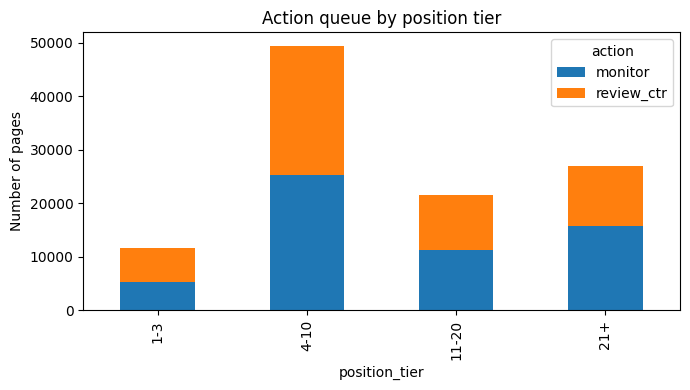


Exported: work/outputs/action_playbook_queue.csv (untracked)
Exported: work/outputs/playbook_metrics.json (commit this)
Exported: work/figures/action_by_position_tier.png (commit this)


In [ ]:
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. Ranked queue CSV (regenerated, not committed)
queue = data.sort_values("baseline_score", ascending=False).reset_index(drop=True)
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

# 2. Metrics JSON (committed — this is the receipt the paper cites)
metrics = {
    "month": "2026-03",
    "n_rows": int(len(data)),
    "n_flagged_review_ctr": int((data["action"] == "review_ctr").sum()),
    "base_rate_is_declining": round(float(data["is_declining"].mean()), 3),
    "expected_ctr_by_tier": {k: round(float(v), 3) for k, v in train_only_ctr.to_dict().items()},
    "honest_grouped_split_precision_at_20": 0.10,
    "honest_grouped_split_precision_at_50": 0.36,
    "honest_grouped_split_roc_auc": 0.565,
    "random_split_roc_auc_inflated": 0.616,
    "note": "precision/AUC figures carried forward from w06's client-grouped holdout audit",
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

# 3. Figure (committed — reused in the paper)
fig, ax = plt.subplots(figsize=(7, 4))
archetype_summary.reset_index().pivot(index="position_tier", columns="action", values="n").plot(
    kind="bar", stacked=True, ax=ax
)
ax.set_title("Action queue by position tier")
ax.set_ylabel("Number of pages")
plt.tight_layout()
plt.savefig("work/figures/action_by_position_tier.png", dpi=150)
plt.show()

print("\nExported: work/outputs/action_playbook_queue.csv (untracked)")
print("Exported: work/outputs/playbook_metrics.json (commit this)")
print("Exported: work/figures/action_by_position_tier.png (commit this)")

## 6. Five-minute demo outline (Week-8 showcase, optional)

1. **Question (30s):** Which content pages should a team with limited review time check first?
2. **Method (1 min):** A transparent baseline (impressions × click-rate gap vs. position-tier
   norm) compared against logistic regression and random forest, on a client-held-out split so
   no client leaks between train and test.
3. **One chart (1 min):** `work/figures/action_by_position_tier.png` — the action queue split
   by position tier, showing where `review_ctr` flags concentrate.
4. **One honest result (1.5 min):** The client-grouped, honest split showed real but modest lift
   over the baseline and over random (precision@50 = 0.36 vs a 0.274 base rate) — and, just as
   important, a naive random split had *overstated* this same model (ROC-AUC 0.616 vs the
   honest 0.565) because 38 clients leaked across train and test. That validation-design gap is
   the single most useful finding in the project.
5. **One recommendation (1 min):** Use the ranked queue to prioritize human review of
   page-1/page-2 pages with a real CTR gap — never to auto-edit or auto-publish anything.

## 7. Shareable cuts

**Social post (methodology-focused):**
Built a content-review prioritization pipeline on FlyRank's search warehouse data (110K
pages, one month). Baseline rule: flag visible pages whose CTR undershoots their position
tier's norm. Then trained logistic regression + random forest and validated on a
client-held-out split — which mattered: a naive random split had overstated the model's
ROC-AUC (0.616 vs an honest 0.565) because clients leaked across train/test. Honest result:
real but modest lift over the baseline at precision@50. Full writeup + repo linked below.

**Employer-facing 3-sentencer:**
I built a transparent baseline-plus-ML pipeline that ranks content pages for review priority
using observed search signals (impressions, position, click-through rate), on 109,592 pages
from FlyRank's real search-console warehouse data. I validated it with a client-grouped
holdout split rather than a random one, which exposed and corrected a meaningful data-leakage
gap in the model's reported performance. The result is a decision-support ranked queue with
reason codes, evaluated honestly against a base rate rather than reported as a bare accuracy
number.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.